## Predicting Survival on the Titanic

### History
Perhaps one of the most infamous shipwrecks in history, the Titanic sank after colliding with an iceberg, killing 1502 out of 2224 people on board. Interestingly, by analysing the probability of survival based on few attributes like gender, age, and social status, we can make very accurate predictions on which passengers would survive. Some groups of people were more likely to survive than others, such as women, children, and the upper-class. Therefore, we can learn about the society priorities and privileges at the time.

### Assignment:

Build a Machine Learning Pipeline, to engineer the features in the data set and predict who is more likely to Survive the catastrophe.

Follow the Jupyter notebook below, and complete the missing bits of code, to achieve each one of the pipeline steps.

In [188]:
import re

# to handle datasets
import seaborn as sns
import pandas as pd
import numpy as np
import requests
import os

# for visualization
import matplotlib.pyplot as plt

# to divide train and test set
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import OneHotEncoder

from sklearn.model_selection import GridSearchCV

# feature scaling
from sklearn.preprocessing import StandardScaler

# to build the models
from sklearn.linear_model import LogisticRegression

from sklearn.pipeline import Pipeline

# to evaluate the models
from sklearn.metrics import accuracy_score, roc_auc_score, recall_score

# to persist the model and the scaler
import joblib

# to visualise al the columns in the dataframe
pd.pandas.set_option('display.max_columns', None)

## Prepare the data set

In [189]:
# URL for the Titanic dataset
url = "https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv"

# Ensure the '../data' directory exists
os.makedirs('../data', exist_ok=True)  # Creates folder if it doesn't exist

try:
    # Download the dataset
    response = requests.get(url)
    response.raise_for_status()  # Check for HTTP errors

    # Save to '../data/titanic_data.csv'
    with open('../data/titanic_data.csv', 'wb') as f:
        f.write(response.content)

    print("Dataset saved successfully to ../data/titanic_data.csv")
except requests.exceptions.RequestException as e:
    print("Failed to download the dataset:", e)
except Exception as e:
    print("An error occurred:", e)

Dataset saved successfully to ../data/titanic_data.csv


In [190]:
# load the data - it is available open source and online
data = pd.read_csv('../data/titanic_data.csv')
data.head()

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


In [191]:
# replace interrogation marks by NaN values
data = data.replace('?', np.nan)

In [192]:
# retain only the first cabin if more than
# 1 are available per passenger
# def get_first_cabin(row):
#    try:
#        return row.split()[0]
#    except:
#        return np.nan
#
# data['cabin'] = data['cabin'].apply(get_first_cabin)

In [193]:
# extracts the title (Mr, Ms, etc) from the name variable

def get_title(passenger):
    line = passenger
    if re.search('Mrs', line):
        return 'Mrs'
    elif re.search('Mr', line):
        return 'Mr'
    elif re.search('Miss', line):
        return 'Miss'
    elif re.search('Master', line):
        return 'Master'
    else:
        return 'Other'
    
data['Title'] = data['Name'].apply(get_title)

In [194]:
# cast numerical variables as floats

data['Fare'] = data['Fare'].astype('float')
data['Age'] = data['Age'].astype('float')
data['Pclass'] = data['Pclass'].astype('str')

In [195]:
data.head()

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,Title
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500,Mr
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833,Mrs
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250,Miss
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000,Mrs
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500,Mr


In [196]:
# drop unnecessary variables

data.drop(labels=['Name'], axis=1, inplace=True)

# display data
data.head()

,Survived,Pclass,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,Title
0,0,3,male,22.0,1,0,7.2500,Mr
1,1,1,female,38.0,1,0,71.2833,Mrs
2,1,3,female,26.0,0,0,7.9250,Miss
3,1,1,female,35.0,1,0,53.1000,Mrs
4,0,3,male,35.0,0,0,8.0500,Mr


In [197]:
# save the data set

# data.to_csv('titanic.csv', index=False)

## Data Exploration

### Find numerical and categorical variables

In [198]:
target = 'Survived'

In [199]:
vars_num = [var for var in data.columns if data[var].dtype != "O" and  var != "Pclass" and var != target]

vars_cat = [var for var in data.columns if (data[var].dtype == "O"
                                            or var == "Pclass"
                                            ) and  var != target]

print('Number of numerical variables: {}'.format(len(vars_num)))
print('Number of categorical variables: {}'.format(len(vars_cat)))

Number of numerical variables: 4
Number of categorical variables: 3


### Find missing values in variables

In [200]:
# first in numerical variables
missing_num_values = data[vars_num].isnull().sum()
print("Missing Values:\n", missing_num_values)

Missing Values:
 Age                        0
Siblings/Spouses Aboard    0
Parents/Children Aboard    0
Fare                       0
dtype: int64


In [201]:
# now in categorical variables
missing_cat_values = data[vars_cat].isnull().sum()
print("Missing Values:\n", missing_cat_values)


Missing Values:
 Pclass    0
Sex       0
Title     0
dtype: int64


### Determine cardinality of categorical variables

In [202]:
categorical_vars = data[vars_cat]

cardinality = categorical_vars.nunique()

print("Cardinality of Categorical Variables:\n")
print(cardinality)

Cardinality of Categorical Variables:

Pclass    3
Sex       2
Title     5
dtype: int64


### Determine the distribution of numerical variables

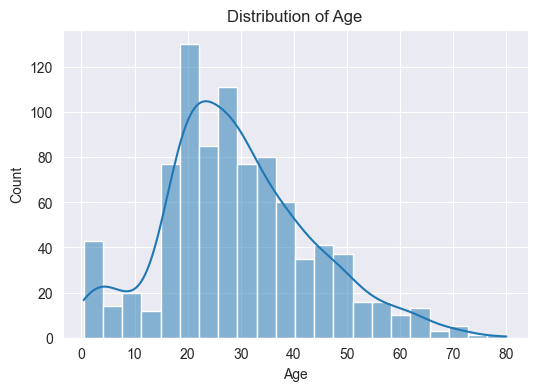

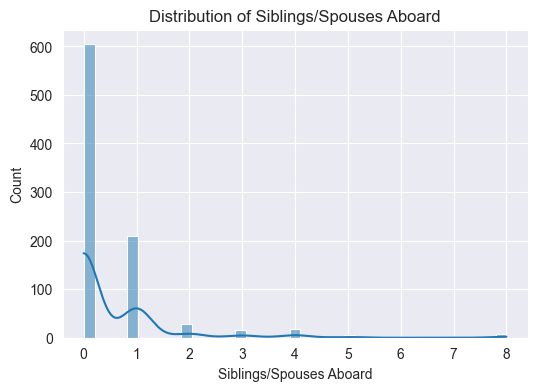

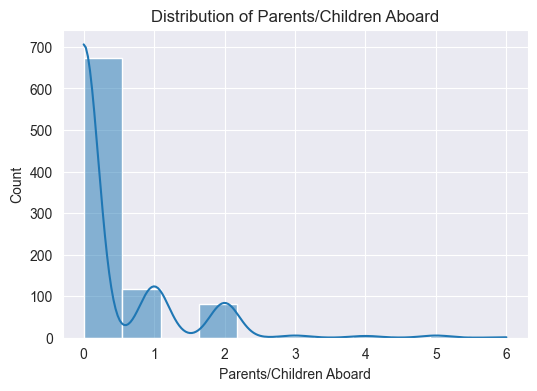

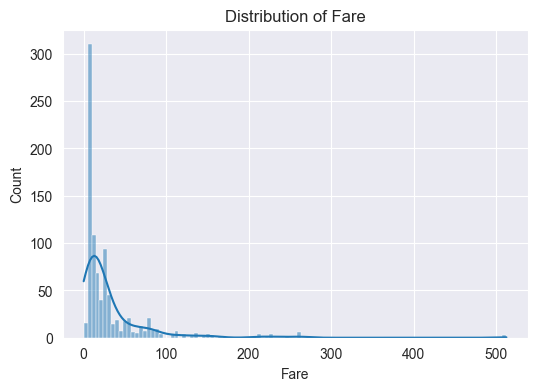

In [203]:
for col in vars_num:
    plt.figure(figsize=(6,4))
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()


## Separate data into train and test

Use the code below for reproducibility. Don't change it.

In [204]:
X_train, X_test, y_train, y_test = train_test_split(
    data.drop('Survived', axis=1),  # predictors
    data['Survived'],  # target
    test_size=0.2,  # percentage of obs in test set
    random_state=0)  # seed to ensure reproducibility

X_train.shape, X_test.shape

((709, 7), (178, 7))

## Feature Engineering

### Extract only the letter (and drop the number) from the variable Cabin

### Fill in Missing data in numerical variables:

- Add a binary missing indicator
- Fill NA in original variable with the median

In [205]:
# For each numerical variable
for col in vars_num:

    # Create Missing Indicator Column
    data[col + '_na'] = data[col].isnull().astype(int)

    # Fill missing values with Median
    median_value = data[col].median()
    data[col] = data[col].fillna(median_value)

print("Missing values handled successfully!")

Missing values handled successfully!


### Replace Missing data in categorical variables with the string **Missing**

In [206]:
# Select categorical columns automatically
vars_cat = data.select_dtypes(include=['object', 'category']).columns

# Fill missing values
data[vars_cat] = data[vars_cat].fillna('Missing')

print("Missing values in categorical variables replaced with 'Missing'")


Missing values in categorical variables replaced with 'Missing'


### Remove rare labels in categorical variables

- remove labels present in less than 5 % of the passengers

In [207]:
threshold = 0.05  # 5%

for col in vars_cat:
    # Calculate frequency
    freq = data[col].value_counts(normalize=True)

    # Identify rare labels
    rare_labels = freq[freq < threshold]

    # Calculate total rare percentage
    rare_percentage = rare_labels.sum() * 100

    print(f'Column: {col}')
    print(f'Rare Labels:\n{rare_labels}')
    print(f'Percentage of Rare Labels: {rare_percentage:.2f}%')
    print('-'*50)


Column: Pclass
Rare Labels:
Series([], Name: proportion, dtype: float64)
Percentage of Rare Labels: 0.00%
--------------------------------------------------
Column: Sex
Rare Labels:
Series([], Name: proportion, dtype: float64)
Percentage of Rare Labels: 0.00%
--------------------------------------------------
Column: Title
Rare Labels:
Title
Master    0.045096
Other     0.030440
Name: proportion, dtype: float64
Percentage of Rare Labels: 7.55%
--------------------------------------------------


In [208]:
# Threshold for rare label
threshold = 0.05  # 5%

# Loop through each categorical variable
for col in vars_cat:
    # Find labels that appear in less than 5% of rows
    freq = data[col].value_counts(normalize=True)
    rare_labels = freq[freq < threshold].index

    # Remove rows where column value is a rare label
    data = data[~data[col].isin(rare_labels)]

print("Rows with rare labels removed successfully!")


Rows with rare labels removed successfully!


### Perform one hot encoding of categorical variables into k-1 binary variables

- k-1, means that if the variable contains 9 different categories, we create 8 different binary variables
- Remember to drop the original categorical variable (the one with the strings) after the encoding

In [209]:
# Initialize encoder for k-1 encoding
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Fit and transform categorical variables
encoded_array = encoder.fit_transform(data[vars_cat])

# Convert to DataFrame
encoded_df = pd.DataFrame(encoded_array, columns=encoder.get_feature_names_out(vars_cat), index=data.index)

# Drop original categorical variables
data.drop(columns=vars_cat, inplace=True)

# Concatenate encoded variables with original data
data = pd.concat([data, encoded_df], axis=1)

print("One Hot Encoding using sklearn completed!")

One Hot Encoding using sklearn completed!


In [210]:
data.head()

,Survived,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare,Age_na,Siblings/Spouses Aboard_na,Parents/Children Aboard_na,Fare_na,Pclass_2,Pclass_3,Sex_male,Title_Mr,Title_Mrs
0,0,22.0,1,0,7.2500,0,0,0,0,0.0,1.0,1.0,1.0,0.0
1,1,38.0,1,0,71.2833,0,0,0,0,0.0,0.0,0.0,0.0,1.0
2,1,26.0,0,0,7.9250,0,0,0,0,0.0,1.0,0.0,0.0,0.0
3,1,35.0,1,0,53.1000,0,0,0,0,0.0,0.0,0.0,0.0,1.0
4,0,35.0,0,0,8.0500,0,0,0,0,0.0,1.0,1.0,1.0,0.0


### Scale the variables

- Use the standard scaler from Scikit-learn

In [211]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(C=1/0.0005, random_state=0, max_iter=1000))
])

## Train the Logistic Regression model

- Set the regularization parameter to 0.0005
- Set the seed to 0

In [212]:
X_train, X_test, y_train, y_test = train_test_split(
    data.drop('Survived', axis=1),  # predictors
    data['Survived'],  # target
    test_size=0.2,  # percentage of obs in test set
    random_state=0)  # seed to ensure reproducibility

X_train.shape, X_test.shape

((656, 13), (164, 13))

In [213]:
# Define the parameter grid
param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],  # Regularization strength
    'model__penalty': ['l2'],             # Penalty type
    'model__solver': ['lbfgs', 'liblinear'], # Solvers
    'model__max_iter': [100, 300, 500, 1000]  # Number of iterations
}

# Setup GridSearchCV
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='recall', n_jobs=-1)

# Fit
grid_search.fit(X_train, y_train)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Hyperparameters: {'model__C': 10, 'model__max_iter': 100, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
Best Score: 0.7265306122448979


In [214]:
best_model = grid_search.best_estimator_

y_pred = best_model.predict(X_test)

## Make predictions and evaluate model performance

Determine:
- roc-auc
- accuracy

**Important, remember that to determine the accuracy, you need the outcome 0, 1, referring to survived or not. But to determine the roc-auc you need the probability of survival.**

In [215]:
print("Test Recall:", recall_score(y_test, y_pred))
print("Test Roc-Auc:", roc_auc_score(y_test, y_pred))
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Test Recall: 0.8064516129032258
Test Roc-Auc: 0.8640101201771031
Test Accuracy: 0.8780487804878049


That's it! Well done

**Keep this code safe, as we will use this notebook later on, to build production code, in our next assignement!!**